# Nodal surfaces of antisymmetric wavefunctions

Tools live in `physics/nodal.py` (analysis), `plotting/nodal.py` (figures) and `physics/nodal_models.py` (small wavefunctions with known nodes).
A wavefunction is any JAX callable `psi(R) -> (sign, log|psi|)` on one configuration `R` of shape `(n_particles, dim)`,
with `spins[i] ∈ {0, 1}` labelling which particles are exchangeable.

- **Visualize**: slices through configuration space (`slice_grid`, `plot_particle_slice`), 3D nodal surfaces seen by one particle (`plot_particle_isosurface`).
- **Topology**: `cell_census` certifies node-free exchanges $P$, i.e. elements of the stabilizer $G$ of a nodal cell $\Omega$. The cells $P\Omega$ correspond to cosets of $G$ in $S_{N_\uparrow}\times S_{N_\downarrow}$, so certified exchanges bound the number of cells (for a ground state, tiling makes these all the cells).
- **Geometry / comparison**: `node_distance` ($|\psi|/|\nabla\psi|$), `sign_agreement`, `antisymmetry_error`.

In [1]:
from pathlib import Path
import sys
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "physics" / "nodal.py").exists())
sys.path.insert(0, str(root))

import numpy as onp
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

from physics import nodal, nodal_models as models
from plotting import nodal as plot_nodal

%config InlineBackend.figure_format = 'retina'
key = jax.random.PRNGKey(0)

## 1. Three fermions on a line

For the harmonic trap, $\psi \propto \prod_{i<j}(x_j - x_i)\, e^{-\sum x_i^2/2}$: the node is exactly the coincidence planes $x_i = x_j$ and there are $3! = 6$ nodal cells (the particle orderings).
The plane orthogonal to the centre of mass shows all three planes as lines through the origin.

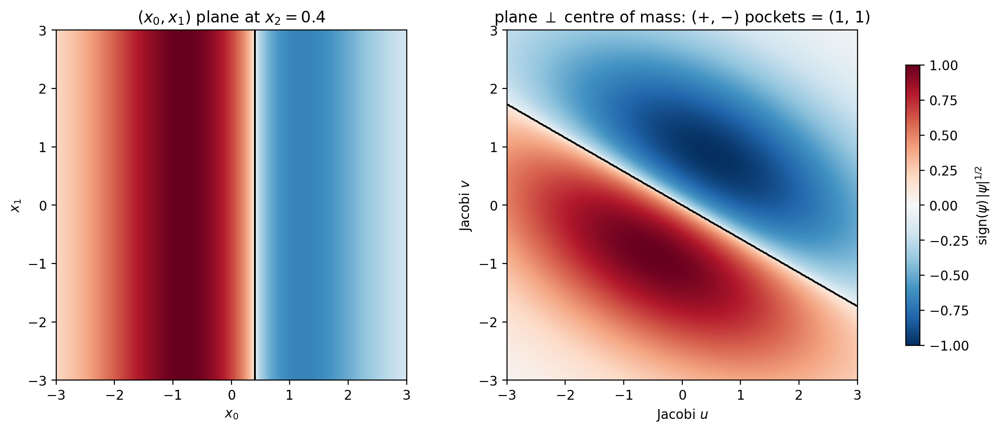

In [22]:
psi_1d = models.slater_determinant(models.harmonic_orbitals(1, 3), spins=[1, 2, 1])

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5), layout="constrained")
R = jnp.array([[0.0], [0.0], [0.4]])
im = plot_nodal.plot_signed(axs[0], *nodal.slice_grid(psi_1d, *nodal.coordinate_plane(R, (0, 0), (1, 0)), 3.0))
axs[0].set(xlabel="$x_0$", ylabel="$x_1$", title="$(x_0, x_1)$ plane at $x_2 = 0.4$")

d1, d2 = nodal.jacobi_plane(3)
grid = nodal.slice_grid(psi_1d, jnp.zeros((3, 1)), d1, d2, 3.0, n=200)
plot_nodal.plot_signed(axs[1], *grid)
axs[1].set(xlabel="Jacobi $u$", ylabel="Jacobi $v$",
           title=rf"plane $\perp$ centre of mass: (+, −) pockets = {nodal.count_pockets(grid[2])}")
fig.colorbar(im, ax=axs, shrink=0.8, label=r"sign$(\psi)\,|\psi|^{1/2}$");

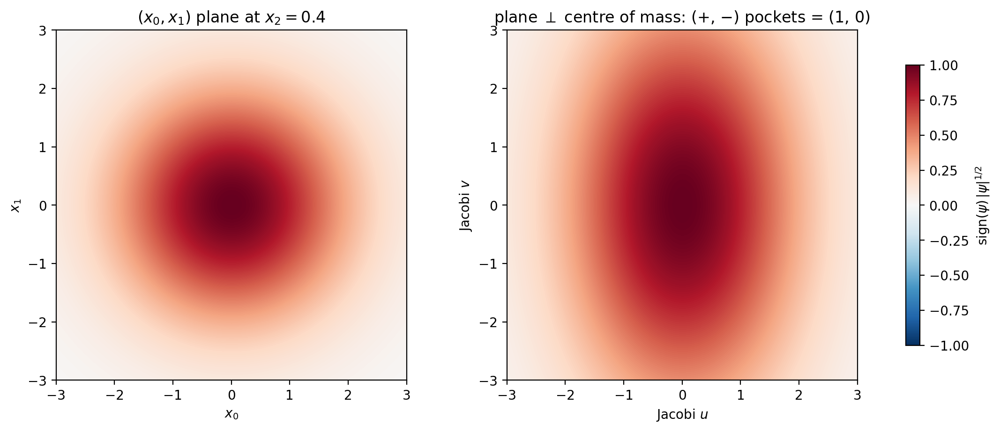

In [16]:
psi_1d = models.slater_determinant(models.harmonic_orbitals(1, 3), spins=[1, 0, -1])

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5), layout="constrained")
R = jnp.array([[0.0], [0.0], [0.4]])
im = plot_nodal.plot_signed(axs[0], *nodal.slice_grid(psi_1d, *nodal.coordinate_plane(R, (0, 0), (1, 0)), 3.0))
axs[0].set(xlabel="$x_0$", ylabel="$x_1$", title="$(x_0, x_1)$ plane at $x_2 = 0.4$")

d1, d2 = nodal.jacobi_plane(3)
grid = nodal.slice_grid(psi_1d, jnp.zeros((3, 1)), d1, d2, 3.0, n=200)
plot_nodal.plot_signed(axs[1], *grid)
axs[1].set(xlabel="Jacobi $u$", ylabel="Jacobi $v$",
           title=rf"plane $\perp$ centre of mass: (+, −) pockets = {nodal.count_pockets(grid[2])}")
fig.colorbar(im, ax=axs, shrink=0.8, label=r"sign$(\psi)\,|\psi|^{1/2}$");

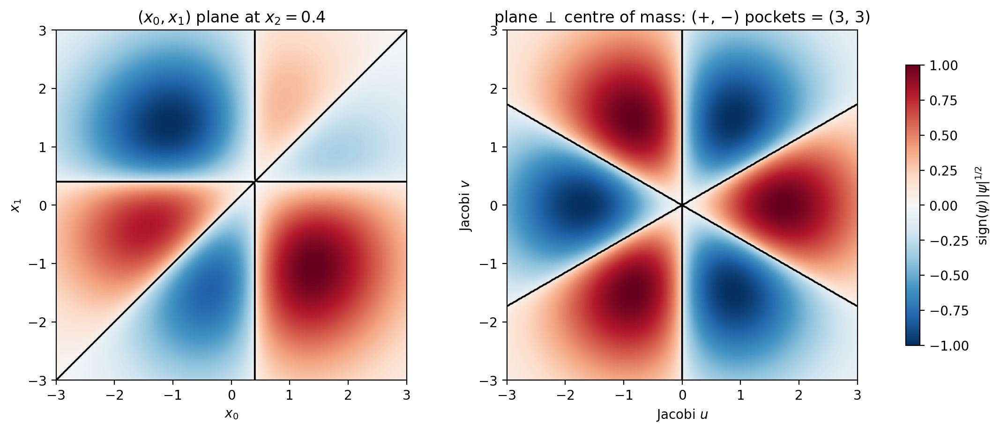

In [2]:
psi_1d = models.slater_determinant(models.harmonic_orbitals(1, 3), spins=[0, 0, 0])

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5), layout="constrained")
R = jnp.array([[0.0], [0.0], [0.4]])
im = plot_nodal.plot_signed(axs[0], *nodal.slice_grid(psi_1d, *nodal.coordinate_plane(R, (0, 0), (1, 0)), 3.0))
axs[0].set(xlabel="$x_0$", ylabel="$x_1$", title="$(x_0, x_1)$ plane at $x_2 = 0.4$")

d1, d2 = nodal.jacobi_plane(3)
grid = nodal.slice_grid(psi_1d, jnp.zeros((3, 1)), d1, d2, 3.0, n=200)
plot_nodal.plot_signed(axs[1], *grid)
axs[1].set(xlabel="Jacobi $u$", ylabel="Jacobi $v$",
           title=rf"plane $\perp$ centre of mass: (+, −) pockets = {nodal.count_pockets(grid[2])}")
fig.colorbar(im, ax=axs, shrink=0.8, label=r"sign$(\psi)\,|\psi|^{1/2}$");

The census cannot certify any exchange in one dimension (particles cannot pass each other without meeting), so its bound is the full group order $3! = 6$, which is exact here.

In [3]:
k1, k2, key = jax.random.split(key, 3)
samples, acc = nodal.metropolis(psi_1d, jax.random.normal(k1, (16, 3, 1)), k1, n_sweeps=200, step=0.5)
print(nodal.cell_census(psi_1d, [0, 0, 0], samples[-1, 0], k2, step=0.5))

S_up x S_down has order 6; certified exchanges generate order 1
  3-cycles: 0/128 certified
nodal cells: at most 6 (at least 2)


## 2. Three same-spin fermions in a 2D trap

Filling the $1s, p_x, p_y$ shell gives $\psi \propto \det[1, x_i, y_i]\, e^{-\sum r_i^2/2}$, the signed area of the triangle $r_0 r_1 r_2$.
The node is "the three particles are collinear", so particle 0 sees the line through particles 1 and 2.
A 3-cycle preserves the triangle's orientation, and the census finds node-free cyclic exchanges: two cells.

S_up x S_down has order 6; certified exchanges generate order 3
  3-cycles: 128/128 certified
nodal cells: 2 (exact)


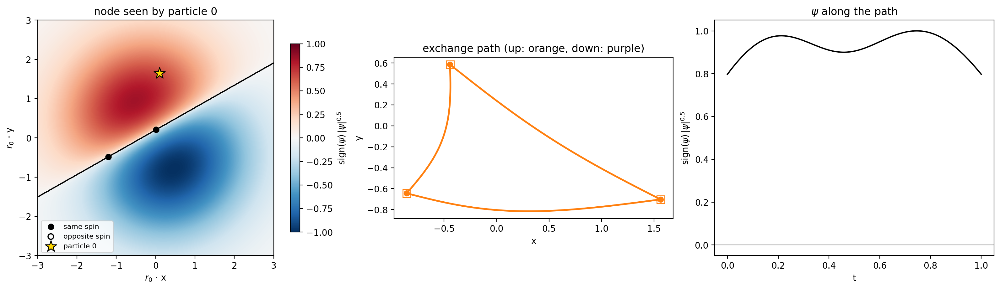

In [4]:
psi_2d = models.slater_determinant(models.harmonic_orbitals(2, 3), spins=[0, 0, 0])
k1, k2, key = jax.random.split(key, 3)
samples, _ = nodal.metropolis(psi_2d, jax.random.normal(k1, (16, 3, 2)), k1, n_sweeps=200, step=0.5)
census_2d = nodal.cell_census(psi_2d, [0, 0, 0], samples[-1, 0], k2, step=0.5)
print(census_2d)

fig, axs = plt.subplots(1, 3, figsize=(16, 4.5), layout="constrained")
plot_nodal.plot_particle_slice(axs[0], psi_2d, samples[-1, 0], 0, [0, 0, 0], extent=3.0)
axs[0].legend(loc="lower left", fontsize=8)
axs[0].set_title("node seen by particle 0")
perm, path = next(iter(census_2d.witnesses.items()))
plot_nodal.plot_exchange_path(psi_2d, path, [0, 0, 0], axs=axs[1:]);

S_up x S_down has order 6; certified exchanges generate order 3
  3-cycles: 128/128 certified
nodal cells: 2 (exact)


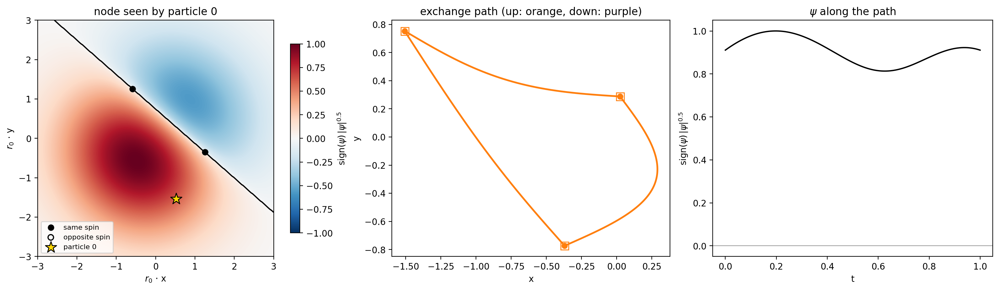

In [26]:
psi_2d = models.slater_determinant(models.harmonic_orbitals(2, 3), spins=[0, 0, 0])
k1, k2, key = jax.random.split(key, 3)
samples, _ = nodal.metropolis(psi_2d, jax.random.normal(k1, (16, 3, 2)), k1, n_sweeps=200, step=0.5)
census_2d = nodal.cell_census(psi_2d, [0, 0, 0], samples[-1, 0], k2, step=0.5)
print(census_2d)

fig, axs = plt.subplots(1, 3, figsize=(16, 4.5), layout="constrained")
plot_nodal.plot_particle_slice(axs[0], psi_2d, samples[-1, 0], 0, [0, 0, 0], extent=3.0)
axs[0].legend(loc="lower left", fontsize=8)
axs[0].set_title("node seen by particle 0")
perm, path = next(iter(census_2d.witnesses.items()))
plot_nodal.plot_exchange_path(psi_2d, path, [0, 0, 0], axs=axs[1:]);

## 3. Beryllium: Hartree–Fock vs. two-configuration nodes

With electrons 0, 1 up and 2, 3 down, the Hartree–Fock determinant $D_\uparrow(1s,2s)\,D_\downarrow(1s,2s)$ vanishes when $|r_0| = |r_1|$ or $|r_2| = |r_3|$: four cells.
Mixing in $1s^2 2p^2$ (here $c_{2p} = -0.2$) fuses them into two [Bressanini, Ceperley & Reynolds, *What do we know about wave function nodes?* (2002)].

The slices use a hand-picked configuration with the down pair at nearly equal radii, where the $2p^2$ term matters most.
The HF node seen by electron 0 is the sphere $|r_0| = |r_1|$; the two-configuration node tears it open, connecting "inside" to "outside".

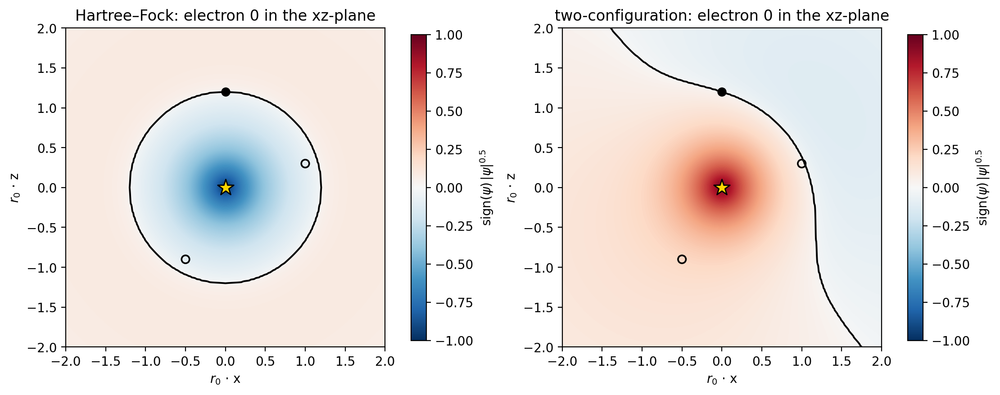

In [5]:
hf, mc = models.beryllium(0.0), models.beryllium(-0.2)
spins_be = [0, 0, 1, 1]
R_be = onp.array([[0.0, 0.0, 0.0],     # electron 0 (up), moved on the grid
                  [0.0, 0.0, 1.2],     # electron 1 (up)
                  [1.0, 0.0, 0.3],     # electrons 2, 3 (down), at nearly equal radii
                  [-0.5, 0.0, -0.9]])

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5), layout="constrained")
for ax, psi, name in [(axs[0], hf, "Hartree–Fock"), (axs[1], mc, "two-configuration")]:
  plot_nodal.plot_particle_slice(ax, psi, R_be, 0, spins_be, axes=(0, 2), extent=2.0)
  ax.set_title(f"{name}: electron 0 in the xz-plane")

In [7]:
from IPython.display import HTML, display

for psi, name in [(hf, "Hartree–Fock"), (mc, "two-configuration")]:
  fig3d = plot_nodal.plot_particle_isosurface(psi, R_be, 0, spins_be, extent=2.0)
  fig3d.update_layout(title=f"{name}: nodal surface seen by electron 0", height=450)
  # fig3d.show() also works once nbformat is installed in the kernel's environment
  display(HTML(fig3d.to_html(include_plotlyjs="cdn", full_html=False)))

In [ ]:
censuses = {}
for psi, name in [(hf, "Hartree–Fock"), (mc, "two-configuration")]:
  k1, k2, key = jax.random.split(key, 3)
  samples, _ = nodal.metropolis(psi, jax.random.normal(k1, (16, 4, 3)), k1, n_sweeps=300, step=0.25)
  censuses[name] = nodal.cell_census(psi, spins_be, samples[-1, 0], k2, step=0.25)
  print(f"--- {name}\n{censuses[name]}\n")

A certified double exchange $(0\,1)(2\,3)$ for the two-configuration wavefunction: both spin pairs swap without crossing the node.
The same search finds nothing for Hartree–Fock, where the swap must cross $|r_0| = |r_1|$ and $|r_2| = |r_3|$.

In [ ]:
perm, path = next(iter(censuses["two-configuration"].witnesses.items()))
plot_nodal.plot_exchange_path(mc, path, spins_be, axes=(0, 2));

### Sign agreement is blind to topology

The two nodes differ only near the self-intersection of the HF node, so the wavefunctions agree in sign almost everywhere, even though the cell structure (4 vs 2) differs.

In [ ]:
k1, key = jax.random.split(key)
samples_mc, _ = nodal.metropolis(mc, jax.random.normal(k1, (256, 4, 3)), k1, n_sweeps=400, step=0.25)
X_mc = samples_mc[100::10].reshape(-1, 4, 3)
print(f"sign agreement, HF vs two-configuration, on {len(X_mc)} samples of |psi_2c|^2: "
      f"{nodal.sign_agreement(hf, mc, X_mc):.4f}")

## 4. Electron gas in a periodic box

Five up and five down electrons in the lowest plane-wave shell of a 2D box of side $L = 2\pi$.
Each spin determinant alone has two cells, but the product has at least four, and the census finds no node-free double exchange.

In [ ]:
L = 2 * onp.pi
spins_heg = [0] * 5 + [1] * 5
heg = models.slater_determinant(models.plane_wave_orbitals(2, 5, L), spins_heg)
k1, k2, key = jax.random.split(key, 3)
samples_heg, acc = nodal.metropolis(heg, jax.random.uniform(k1, (64, 10, 2)) * L, k1, n_sweeps=300, step=0.4)
R_heg = samples_heg[-1, 0] % L   # psi is periodic, so wrap the snapshot into the box

fig, ax = plt.subplots(figsize=(6, 5), layout="constrained")
plot_nodal.plot_particle_slice(ax, heg, R_heg, 0, spins_heg, extent=(0, L, 0, L))
ax.set_title("2D electron gas (5↑ 5↓, HF): node seen by electron 0")
print(nodal.cell_census(heg, spins_heg, R_heg, k2, step=0.4))

### Distance to the node

Near a smooth node $\psi \approx |\nabla\psi|\, s$ with $s$ the signed distance, so under $|\psi|^2$ sampling the density of $d = |\psi|/|\nabla\psi|$ vanishes like $d^2$: the fraction of samples closer than $d$ grows like $d^3$.
(For all-electron atoms $d$ is instead capped near $1/(\zeta_{1s}\sqrt{n_\text{core}})$ by the nuclear cusp, which is why this uses the electron gas.)

In [ ]:
k1, key = jax.random.split(key)
samples_d, _ = nodal.metropolis(heg, jax.random.uniform(k1, (256, 10, 2)) * L, k1, n_sweeps=400, step=0.4)
X_heg = samples_d[100::4].reshape(-1, 10, 2)
d = onp.sort(onp.asarray(nodal.node_distance(heg, X_heg)))
fraction = onp.arange(1, len(d) + 1) / len(d)
x0 = 0.25 * onp.median(d)
C = onp.mean(d < x0) / x0 ** 3               # fraction closer than x ~ C x^3 for small x

fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
ax.loglog(d, fraction, label=f"{len(d)} samples of $|\\psi|^2$")
x = onp.geomspace(d[0], 2 * x0, 50)
ax.loglog(x, C * x ** 3, "k--", label=r"$C\,d^3$")
ax.set(xlabel=r"$d = |\psi| / |\nabla\psi|$", ylabel="fraction of samples closer than $d$")
ax.legend()
print(f"median d = {onp.median(d):.3f}; fraction within 0.1 of the node: {onp.mean(d < 0.1):.4f}")

## Using your own wavefunction

Any JAX callable returning `(sign, log|psi|)` works; check antisymmetry first (handy for neural-network ansätze):

```python
n_bad, log_err = nodal.antisymmetry_error(psi, samples, spins)
```

A jaxqmc `SlaterWF` returns `(log|psi|, sign)` and takes spins explicitly, so `psi = lambda R: wf(R, spins)[::-1]`.
These tools assume a real wavefunction; for a complex one the zero set has codimension two and the fixed-phase analogue applies instead.